### `Compressed Sensing of Images`
Ce notebook explore l’acquisition comprimée (compressed sensing) d’images naturelles, en évaluant plusieurs modèles de parcimonie des coefficients dans une base d’ondelettes afin d’améliorer la qualité de reconstruction à partir d’un nombre réduit de mesures

In [1]:
import sys, os
import numpy as np
toolbox_parent = r"/Users/asriel/TP_IAFA/M2_IAFA/TP_M2IAFA/TP_M2_IMGCMPT/TP23_Imagerie_Computationnelle"
sys.path.insert(0, toolbox_parent)

from nt_toolbox.general import *
from nt_toolbox.signal import *
import nt_toolbox as nt

%matplotlib inline
%load_ext autoreload
%autoreload 2

### `Filtre pass bas mesures linéaires`
Nous utilisons premièrement les mesures d'un filtre passe bas $P$ pour retirer les fréquences basses du contenu de l'image.
 - Les images naturelles ne sont pas seulement parcimonieuses dans le domaine des ondelettes. 
 - Elles présentent également une décroissance rapide des coefficients au fil des échelles. 
 - La graine d'ondelette grossières (passe-bas) concentrent une grande partie de l’énergie de l’image.
 - Il est donc pertinent de mesurer directement les coefficients pass bas
 - Maintenant nous chargeons une image $f \in \mathcal{R}^{n^2}$ de $n \times n$ pixels 

(256, 256)


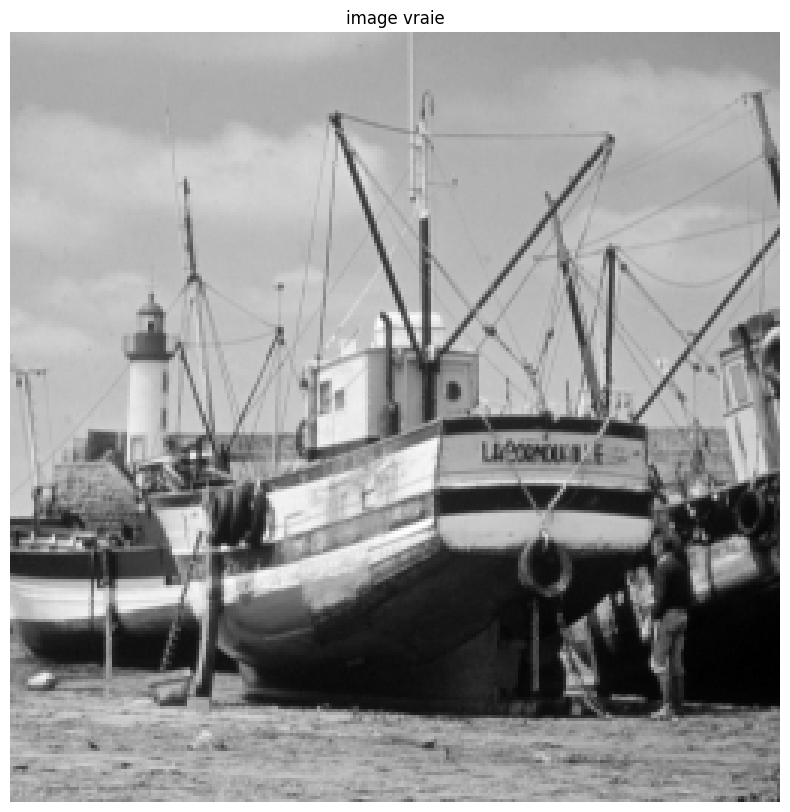

In [47]:
path= '/Users/asriel/TP_IAFA/M2_IAFA/TP_M2IAFA/TP_M2_IMGCMPT/TP23_Imagerie_Computationnelle/'
name = path + 'nt_toolbox/data/boat.bmp'
n = 256
f0 = load_image(name, n)          # f0.shape = (512, 512)
f0 = (f0 - f0.min()) / (f0.max() - f0.min() + 1e-12)
print(f0.shape)

from skimage.transform import rescale

f0_small = rescale(f0, scale=0.5, anti_aliasing=True)   # par ex. moitié moins grand
plt.figure(figsize=(10, 10))
imageplot(clamp(f0),'image vraie')

`Raccourci pour les transoformés en ondelettes` $ \{\dotp{f}{\psi_m}\}_m $.
- Nous calculons la transformée jusqu'à l'échelle $J$ de sorte que seuls les sous-bandes $k_0$ sont transformées.
- Les coefficients d’ondelettes sont des produits scalaires entre le signal et des “briques” de base (ondelettes et fonctions d’échelle).
`Que représente un coefficient`
Pour chaque échelle j et position k :
- $\phi_{J,k}(t)$ : une fonction d’échelle (low-pass) centrée près de la position k, à l’échelle grossière J.
- $\psi_{j,k}(t)$ : une ondelette (petite oscillation localisée) à l’échelle j et position k.

Avec Discrete Wavelet Transform 1D, les coefficients [cA_J, cD_J, cD_{J-1}, ..., cD_1] obtenus ont pour signification : 
`cA_J :` 
- coefficients d’approximation au niveau le plus grossier J. 
- ce sont les projections du signal sur les fonctions d’échelle (low-pass), 
- donc le contenu “lent”, les grandes structures / tendance globale.

`cD_j :` 
- coefficients de détail au niveau j. 
- ce sont les projections sur les ondelettes à l’échelle $2^j$, 
- donc le contenu “rapide” autour de cette échelle, variations locales, détails, singularités.

Intuition par niveau :
- `cD_1` : détails les plus fins (hautes fréquences, bruit, petits bords).
- `cD_2` : un peu plus grossier, etc.
- `cD_J` : détails relativement grossiers, structures un peu plus larges.
- `cA_J` : ce qui reste après avoir filtré tous ces détails, une version très lissée du signal.

Mathématiquement, nous avons une décomposition du type : $\large f(t) = \sum_{k} cA_J[k]\,\phi_{J,k}(t) + \sum_{j=1}^{J} \sum_{k} cD_j[k]\,\psi_{j,k}(t)$
- où $\phi_{J,k}$ sont les fonctions d’échelle et $\psi_{j,k}$ les ondelettes.
- le premier bloc concatèné correspond à cA_J (approximation grossière).
- les blocs suivants sont cD_1, cD_2, ..., cD_J (détails de plus en plus grossiers suivant l'ordre).

In [40]:
import pywt
import numpy as np

def perform_direct_wavelet_transf(f,n,k0=2,wavelet='sym8'):
    wavelet = wavelet  # par ex., à adapter à ce que fait options.wavelet
    w = pywt.Wavelet(wavelet)
    J = int(np.log2(n)-k0)
    print(J)
    # 2D image : f is 2D array
    coeffs_ti_2d = pywt.wavedec2(f, wavelet=w, level=J, mode='symmetric')
    return coeffs_ti_2d, wavelet


def perform_inverse_wavelet_transf(coeffs,wavelet='sym8'):
    # 2D image : f is 2D array
    f_rec = pywt.waverec2(coeffs, wavelet=wavelet, mode='symmetric')
    return f_rec

- `perform_direct_wavelet_transf` transformée directe est un opérateur qui prend une image f et renvoie ses coefficients d’ondelettes.
- `perform_inverse_wavelet_transf` l’opérateur inverse qui à partir des coefficients d’ondelettes, reconstruit l’image, en appelant.

`Calculer la transformée en ondelette.`

In [41]:
coeffs_ti_2d, wavelet = perform_direct_wavelet_transf(f0_small,n)
print(coeffs_ti_2d[0].shape)
f_rec = perform_inverse_wavelet_transf(coeffs_ti_2d,wavelet)

6
(16, 16)


In [ ]:
import numpy as np
import pywt
import matplotlib.pyplot as plt

def show_wavelet_coeffs(coeffs):
    # coeffs = [cA_J, (cH_J,cV_J,cD_J), ..., (cH_1,cV_1,cD_1)]
    cA, details = coeffs[0], coeffs[1:]

    # on part de l'approximation grossière
    rows, cols = cA.shape
    out = np.zeros((rows * 2, cols * 2), dtype=float)
    out[:rows, :cols] = cA

    r, c = rows, cols
    for (cH, cV, cD) in details:
        out[:r, c:2*c]   = cH
        out[r:2*r, :c]   = cV
        out[r:2*r, c:2*c] = cD
        r *= 2
        c *= 2

    plt.figure()
    plt.imshow(out, cmap='gray')
    plt.title('Wavelet coefficients')
    plt.axis('off')
    plt.show()

# usage
show_wavelet_coeffs(coeffs_ti_2d)

Display the coefficients.

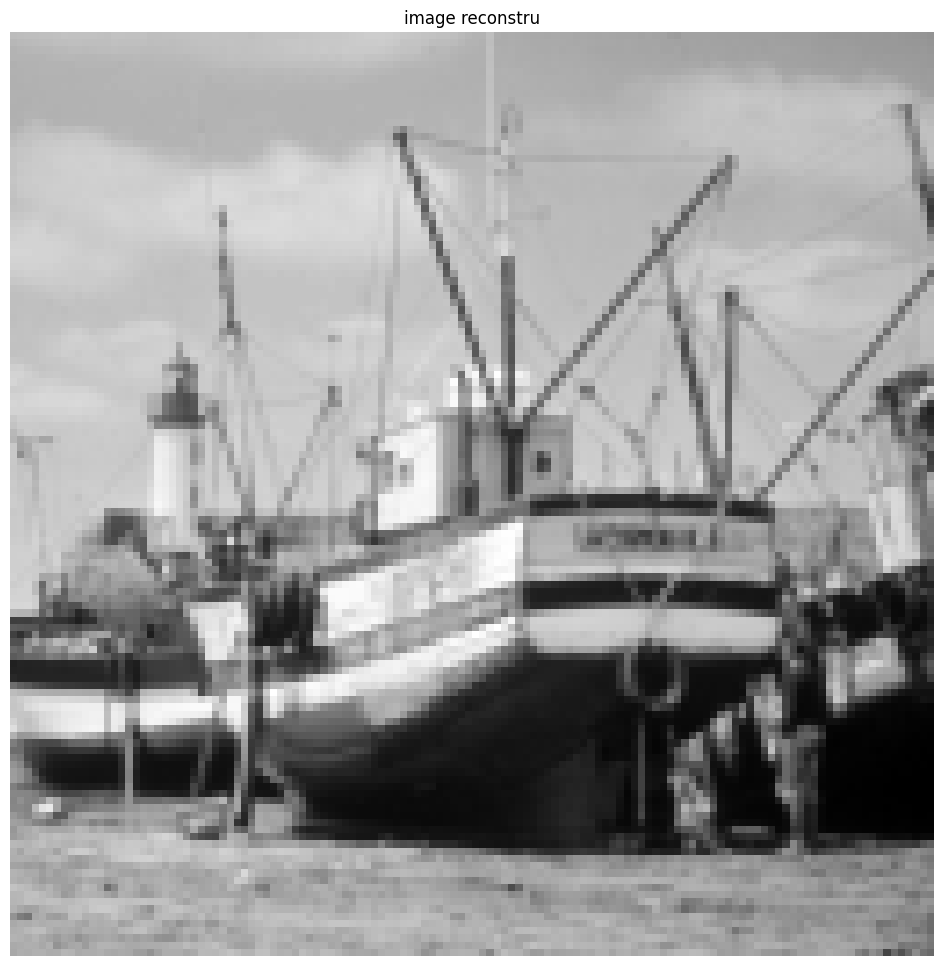

In [ ]:
plot_wavelet(fw, J)

__Exercise 1__

Compute an approximation |fLow| using the $ P=2^{2J}=(n/k_0)^2 $ low pass
coefficients.

In [ ]:
solutions.exo1()

In [ ]:
## Insert your code here.

Randomized Orthogonal Measurements
----------------------------------
We consider a compressed sensing operator that corresponds to randomized
orthogonal projections.



Extract the high pass wavelet coefficients, $x_0 = \{ \dotp{f}{\psi_m} \}_{m \in I_0}$.

In [ ]:
A = ones(n, n); A(1: 2^J, 1: 2^J) = 0
I0 = find(A = =1)
x0 = fw(I0)

Number of coefficients.

In [ ]:
N = length(x0)

Number $ P_0 = 2^{2J}=(n/k_0)^2 $ of low pass measurements.

In [ ]:
P0 = (n/ 2^k0)^2

Number of CS measurements.

In [ ]:
P = 4 * P0

Generate random permutation operators $S_1,S_2 : \RR^N \rightarrow \RR^N$
so that $S_k(x)_i = x_{\sigma_k(i)}$ where $ \sigma_k \in \Sigma_N $
is a random permutation of $\{1,\ldots,N\}$.

In [ ]:
sigma1 = randperm(N)'
sigma2 = randperm(N)'
S1 = lambda x: x(sigma1)
S2 = lambda x: x(sigma2)

The adjoint (and also inverse) operators $S_1^*,S_2^*$ (denoted |S1S,S2S|)
corresponds to the inverse permutation $\sigma_k^*$ such that $\sigma_k^* \circ \sigma_k(i)=i$.

In [ ]:
sigma1S = 1: N; sigma1S(sigma1) = 1: N
sigma2S = 1: N; sigma2S(sigma2) = 1: N
S1S = lambda x: x(sigma1S)
S2S = lambda x: x(sigma2S)

We consider a CS operator $ \Phi : \RR^N \rightarrow
\RR^P $ that corresponds to a projection on randomized atoms
$$ (\Phi x)_i = \dotp{x}{ \phi_{\sigma_2(i)}} $$
where $ \phi_i $ is a scrambled orthogonal basis
$$ \phi_i(x) = c_i( \sigma_1(x) ) $$
where $\{ c_i \}_i$ is the orthogonal DCT basis.


This can be rewritten in compact operator form as
$$ \Phi x = ( S_2 \circ C \circ S_1 (x) ) \downarrow_P $$
where $S_1,S_2$ are the permutation operators, and $\downarrow_P$
selects the $P$ first entries of a vector.

In [ ]:
downarrow = lambda x: x(1: P)
Phi = lambda x: downarrow(S2(dct(S1(x))))

The adjoint operator is
$$ \Phi^* x = S_1^* \circ C^* \circ S_2^* (x\uparrow_P) $$
where $\uparrow_P$ append $N-P$ zeros at the end of a vector, and
$C^*$ is the inverse DCT transform.

In [ ]:
uparrow = lambda x: [x; zeros(N-P, 1)]
PhiS = lambda x: S1S(idct(S2S(uparrow(x))))

Perform the CS (noiseless) measurements.

In [ ]:
y = Phi(x0)

__Exercise 2__

Reconstruct an image using the pseudo inverse coefficients $\Phi^+ y =
\Phi^* y$.

In [ ]:
solutions.exo2()

In [ ]:
## Insert your code here.

Compressed Sensing Recovery using Douglas Rachford Scheme
---------------------------------------------------------
We consider the minimum $\ell^1$ recovery from the measurements $y = \Phi x_0 \in \RR^P$
$$ \umin{\Phi x = y} \normu{x}. $$
This can be written as
$$ \umin{ x } F(x) + G(x) \qwhereq
\choice{
      F(x) = i_{\Cc}(x), \\
      G(x) = \normu{x}.
  }
$$
where $\Cc = \enscond{x}{\Phi x =y}$.


One can solve this problem using the Douglas-Rachford iterations
$$ \tilde x_{k+1} = \pa{1-\frac{\mu}{2}} \tilde x_k +
  \frac{\mu}{2} \text{rPox}_{\gamma G}( \text{rProx}_{\gamma F}(\tilde x_k)  )
  \qandq x_{k+1} = \text{Prox}_{\gamma F}(\tilde x_{k+1},) $$


We have use the following definition for the proximal and
reversed-proximal mappings:
$$ \text{rProx}_{\gamma F}(x) = 2\text{Prox}_{\gamma F}(x)-x $$
$$ \text{Prox}_{\gamma F}(x) = \uargmin{y} \frac{1}{2}\norm{x-y}^2 + \ga F(y). $$


One can show that for any value of $\gamma>0$, any $ 0 < \mu < 2 $,
and any $\tilde x_0$, $x_k \rightarrow x^\star$
which is a solution of the minimization of $F+G$.

__Exercise 3__

Implement the proximal and reversed-proximal mappings of $F$ (the orthogonal projector on
$\Cc$ and $G$ (soft thresholding). In Matlab, use inline function with the |@|
operator.

In [ ]:
solutions.exo3()

In [ ]:
## Insert your code here.

Value for the $0 < \mu < 2$ and $\gamma>0$ parameters.
You can use other values, this might speed up the convergence.

In [ ]:
mu = 1
gamma = 1

__Exercise 4__

Implement the DR iterative algorithm.
Keep track of the evolution of the $\ell^1$ norm $G(x_k)$.

In [ ]:
solutions.exo4()

In [ ]:
## Insert your code here.

__Exercise 5__

Display the image reconstructed using the $P_0$ linear and $P$ CS
measurements. The total number of used measurements is thus $P+P_0$.

In [ ]:
solutions.exo5()

In [ ]:
## Insert your code here.

Compressed Sensing Reconstruction using Block Sparsity
------------------------------------------------------
In order to enhance the CS reconstruction, it is possible to use more
advanced priors than plain $ \ell^1 $.


One can for instance use a block $ \ell^1 $ norm
$$ G(x) = \sum_i \norm{x_{B_i}} $$
where $ (B_i)_i $ is a disjoint segmentation of the index set $
\{1,\ldots,N\} $, where
$x_{B} = \{ x_i \}_{i \in B} \in \RR^{|B|}$ extracts the coefficients
within $B$, and $ \norm{x_B} $ is the $\ell^2$ norm.


The proximal operator of this block $\ell^1$ norm is a block
thresholding
$$ \forall \, m \in B_i, \quad \text{Prox}_{\ga G}(x)_i =
  \max(0, 1-\ga/\norm{x_{B_i}}) x_i. $$


We use uniform blocks of size $w \times w$.

In [ ]:
w = 4

Blocks position and offset in the image domain.

In [ ]:
v = 1: w: n
dv = 0: w-1
[dX, dY, X, Y] = ndgrid(dv, dv, v, v)
q = size(X, 3)
dX = reshape(dX, [w*w q*q])
dY = reshape(dY, [w*w q*q])
X = reshape(X, [w*w q*q])
Y = reshape(Y, [w*w q*q])

Remove the block which fails outside the image.

In [ ]:
I = find(sum(X + dX >n | Y + dY >n))
X(: , I) = []
Y(: , I) = []
dX(: , I) = []
dY(: , I) = []

Compute the indexes of the block in $\{1,\ldots,N\}$, i.e.  not in image space
but over the CS coefficients space.

In [ ]:
U = zeros(n, n)
U(I0) = 1: N
Ind = X + dX + (Y + dY-1)*n
I = U(Ind)

Remove the indexes that corresponds to low pass wavelet coefficients.

In [ ]:
I(: , sum(I = =0) >0) = []

A block is defined as $B_i = \{ I_{k,i} \}_{k=1}^{w^2}$.
Define the energy.

In [ ]:
G = lambda x: sum(sqrt(sum(x(I).^2)))

Just for check : display in coefficient space the block structure.

In [ ]:
[A, tmp] = meshgrid(randperm(size(I, 2)) , ones(w*w, 1))
x = zeros(N, 1); x(I) = A
Z = zeros(n, n); Z(I0) = x

imageplot(Z)
colormap jet(256)

__Exercise 6__

define the proximal operator $ \text{Prox}_{\ga G} $ of $G$,
and its reversed proximal mapping.

In [ ]:
solutions.exo6()

In [ ]:
## Insert your code here.

__Exercise 7__

Implement the DR iterative algorithm.
Keep track of the evolution of $G(x_k)$.

In [ ]:
solutions.exo7()

In [ ]:
## Insert your code here.

__Exercise 8__

Display the image reconstructed using the $P_0$ linear and $P$ CS
measurements.

In [ ]:
solutions.exo8()

In [ ]:
## Insert your code here.